#**JouleAI G9-LATAM-Team-42**

EnergiAI es un asesor energético automático diseñado para hogares y pequeños negocios. A través de inteligencia artificial, analiza el perfil de consumo eléctrico de los usuarios para clasificar su eficiencia, estimar su gasto mensual y ofrecer recomendaciones personalizadas y accionables de ahorro.

El proyecto es desarrollado como parte de la simulación laboral de No Country por el equipo G9-LATAM-Team-42.

##**Introducción y Objetivos**

Desarrollar un modelo de Machine Learning capaz de clasificar el perfil de consumo energético (Eficiente, Moderado, Ineficiente), estimar la probabilidad, calcular el costo estimado a la tarifa de R$ 0,75/kWh e inferir recomendaciones personalizadas.

##**Generación y Carga de Datos**

###1.1 Importación de Librerías Base
Carga de librerías esenciales para manipulación de datos, análisis numérico y visualización (pandas, numpy, scipy.stats, matplotlib, seaborn).

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import poisson, uniform, norm

import matplotlib.pyplot as plt
import seaborn as sns

###1.2 Generación del Dataset sintético

### **Generación de variables exógenas (independientes)**
Inclusión de variables requeridas por la API: consumo_kwh, uso_horario_pico, cantidad_equipos, tipo_inmueble y horas_alto_consumo.


|Variables |   Tipo de distribución | Parámetros |
| :--- | :---: | ---: |
|Tipo de inmueble| Distribución Multinomial| p = [0.45, 0.30, 0.15, 0.10]|
|Personas por vivienda | Distribución Poisson truncada | λ = 3, truncada [1, 10] |
|Antigüedad del inmueble | Distribución Poisson truncada| λ = 15, truncada [0, 50] |
|Cantidad de equipos| Distribución Poisson truncada | λ = 8, truncada [1, 30]|
| Tiene aire acondicionado | Distribución Bernoulli | p = 0.40 |
| Tiene calentador eléctrico | Distribución Bernoulli | p = 0.30 |
| Electrodomésticos eficientes | Distribución Bernoulli | p = 0.25|
| Uso horario pico | Distribución Bernoulli | p = 0.35 |
| Horas de alto consumo | Distribución Uniforme | [0, 24] |

In [2]:
# Configurar semilla para reproducibilidad
np.random.seed(42)

# Número de registros
n = 5000

# 1. VARIABLES DE CARACTERIZACIÓN DE LA VIVIENDA
# 1.1 Tipo de inmueble - Distribución Multinomial
tipo_inmueble = np.random.choice(
    ['Casa', 'Apartamento', 'Comercio', 'Oficina'],
    n, p=[0.45, 0.30, 0.15, 0.10])

# 1.2 Personas por vivienda - Distribución Poisson truncada
personas_vivienda = poisson.rvs(mu=3, size=n)
personas_vivienda = np.clip(personas_vivienda, 1, 10)

# 1.3 Antigüedad del inmueble - Distribución Poisson truncada
antiguedad_inmueble = poisson.rvs(mu=15, size=n)
antiguedad_inmueble = np.clip(antiguedad_inmueble, 0, 50)

# 2. VARIABLES DE EQUIPAMIENTO
# 2.1 Cantidad de equipos - Distribución Poisson truncada
cantidad_equipos = poisson.rvs(mu=8, size=n)
cantidad_equipos = np.clip(cantidad_equipos, 1, 30)

# 2.2 Tiene aire acondicionado - Distribución Bernoulli
tiene_aire_acondicionado = np.random.binomial(1, 0.40, n)

# 2.3 Tiene calentador eléctrico - Distribución Bernoulli
tiene_calentador_electrico = np.random.binomial(1, 0.30, n)

# 2.4 Electrodomésticos eficientes - Distribución Bernoulli
electrodomesticos_eficientes = np.random.binomial(1, 0.25, n)

# 3. VARIABLES DE COMPORTAMIENTO
# 3.1 Uso horario pico - Distribución Bernoulli
uso_horario_pico = np.random.binomial(1, 0.35, n)

# 3.2 Horas de alto consumo - Distribución Uniforme
horas_alto_consumo = uniform.rvs(0, 24, n)

### **Variable Target de Regresión (consumo_kwh)**

In [3]:
# 4.1 Consumo Base (Ecuación 8.1 del informe)
# C_base = 50 * Personas + 30 * Equipos
consumo_base = (personas_vivienda * 50) + (cantidad_equipos * 30)

# 4.2 Factores Multiplicativos
# Factor por tipo de inmueble (Ecuación 8.2)
factor_tipo = np.select(
    [tipo_inmueble == 'Casa',
     tipo_inmueble == 'Apartamento',
     tipo_inmueble == 'Comercio',
     tipo_inmueble == 'Oficina'],
    [1.2, 1.0, 1.5, 1.3]
)

# Factor por horario pico (Ecuación 8.3)
factor_horario = 1 + 0.3 * uso_horario_pico

# Factor por antigüedad (Ecuación 8.4)
factor_antiguedad = 1 + 0.02 * antiguedad_inmueble

# Factor por equipamiento (Ecuación 8.5)
factor_equipamiento = ((1 + 0.4 * tiene_aire_acondicionado) *
                       (1 + 0.3 * tiene_calentador_electrico) *
                       (1 - 0.2 * electrodomesticos_eficientes))

# 4.3 Consumo Final (Ecuación con ruido)
# Ruido aleatorio: N(0, 100)
ruido = norm.rvs(0, 100, n)

# Ecuación completa del modelo
consumo_kwh = (consumo_base * factor_tipo * factor_horario *
               factor_antiguedad * factor_equipamiento + ruido)

# Recortar valores para mantener realismo
consumo_kwh = np.maximum(consumo_kwh, 50)   # Mínimo 50 kWh
consumo_kwh = np.minimum(consumo_kwh, 2000) # Máximo 2000 kWh
consumo_kwh = np.round(consumo_kwh, 0)      # Redondear a entero

### **Variables derivadas**
Son transformaciones de variables originales que permiten:
- Estandarizar comparaciones entre hogares de diferentes tamanos
- Crear metricas de eficiencia mas interpretables
- Reducir dimensionalidad en analisis exploratorios
- Mejorar el poder predictivo de los modelos

In [4]:
# CREAR VARIABLES DERIVADAS
# 5.1 consumo_promedio_diario (Ecuación 10.1)
consumo_promedio_diario = consumo_kwh / 30

# 5.2 ratio_persona_kwh (Ecuación 10.2)
ratio_persona_kwh = consumo_kwh / personas_vivienda

# 5.3 Variables de interacción (Sección 10.4)
# Carga por equipo (Ecuación 10.3)
carga_por_equipo = consumo_kwh / cantidad_equipos

# Intensidad horaria (Ecuación 10.4)
intensidad_horaria = consumo_kwh / horas_alto_consumo
intensidad_horaria = np.where(np.isinf(intensidad_horaria) | np.isnan(intensidad_horaria),
                              consumo_kwh.mean() / 12, intensidad_horaria)

# 5.4 Variables de agregación (Sección 10.5)
# Consumo promedio por tipo de inmueble (Ecuación 10.6)
consumo_promedio_por_tipo = {}
for tipo in ['Casa', 'Apartamento', 'Comercio', 'Oficina']:
    mask = tipo_inmueble == tipo
    if mask.sum() > 0:
        consumo_promedio_por_tipo[tipo] = consumo_kwh[mask].mean()

# Desviación del promedio por tipo (Ecuación 10.7)
desviacion_promedio_por_tipo = np.zeros(n)
for tipo in ['Casa', 'Apartamento', 'Comercio', 'Oficina']:
    mask = tipo_inmueble == tipo
    if mask.sum() > 0:
        media_tipo = consumo_kwh[mask].mean()
        std_tipo = consumo_kwh[mask].std()
        if std_tipo > 0:
            desviacion_promedio_por_tipo[mask] = (consumo_kwh[mask] - media_tipo) / std_tipo

### **Índice de eficiencia energética (IEE)**

In [5]:
# 8.1 Eficiencia de Equipamiento (Ecuación 11.1)
ee_equipos = (0.4 * electrodomesticos_eficientes +
              0.3 * (1 - antiguedad_inmueble / 50) +
              0.3 * (1 / (1 + cantidad_equipos / 10)))

# 8.2 Eficiencia de Uso (Ecuación 11.2)
ee_uso = (0.5 * (24 - horas_alto_consumo) / 24 +
          0.5 * (1 - uso_horario_pico))

# 8.3 Eficiencia Estructural (Ecuación 11.3)
ee_estructural = (1 / (1 + antiguedad_inmueble / 20) *
                  1 / (1 + personas_vivienda / 5))

# 8.4 Eficiencia de Carga (Ecuación 11.4)
ee_carga = 1 / (1 + ratio_persona_kwh / 200)

# 8.5 IEE Final (Ecuación 11.5)
iee = 100 * (0.35 * ee_equipos +
             0.30 * ee_uso +
             0.20 * ee_estructural +
             0.15 * ee_carga)

# **Crear Dataframe**

Dataframe sin variable target, los valores de target se definiran con umbrales no son números fijos, esto hace la regla menos restrictiva y mejora el balanceo de clases

In [6]:
# Generar IDs
id_usuario = [f"U{i:04d}" for i in range(n)]

# Crear DataFrame con todas las variables
df = pd.DataFrame({
    # Variables base
    'id_usuario': id_usuario,
    'tipo_inmueble': tipo_inmueble,
    'personas_vivienda': personas_vivienda,
    'antiguedad_inmueble': antiguedad_inmueble,
    'cantidad_equipos': cantidad_equipos,
    'tiene_aire_acondicionado': tiene_aire_acondicionado,
    'tiene_calentador_electrico': tiene_calentador_electrico,
    'electrodomesticos_eficientes': electrodomesticos_eficientes,
    'uso_horario_pico': uso_horario_pico,
    'horas_alto_consumo': horas_alto_consumo.round(1),

    # Target de regresión
    'consumo_kwh': consumo_kwh,

    # Variables derivadas
    'consumo_promedio_diario': consumo_promedio_diario.round(1),
    'ratio_persona_kwh': ratio_persona_kwh.round(1),
    'carga_por_equipo': carga_por_equipo.round(1),
    'intensidad_horaria': intensidad_horaria.round(1),

    # IEE
    'iee': iee.round(1)
})

In [7]:
# Correlación IEE vs consumo
corr_iee = df['iee'].corr(df['consumo_kwh'])
print(f"   Correlación IEE vs consumo: {corr_iee:.3f} (esperado ≈ -0.75)")

   Correlación IEE vs consumo: -0.467 (esperado ≈ -0.75)


El IEE muestra una correlación negativa moderada con el consumo (ρ = -0.467, p < 0.001), consistente con la hipótesis de que un mayor índice de eficiencia se asocia a menor consumo. La magnitud moderada refleja que el IEE captura dimensiones adicionales (uso, estructura, equipamiento) que no se reducen únicamente al consumo total.

In [8]:
print(df['tipo_inmueble'].value_counts(normalize=True))

tipo_inmueble
Casa           0.4554
Apartamento    0.2972
Comercio       0.1516
Oficina        0.0958
Name: proportion, dtype: float64


La clasificación se realiza mediante percentiles estratificados por tipo de inmueble. Esto garantiza que 'Eficiente' signifique 'eficiente en comparación con hogares del mismo tipo', evitando sesgos por la composición del dataset. Dado que las casas representan el 45% del dataset y tienen patrones de consumo distintos a comercios u oficinas, una clasificación global favorecería sistemáticamente a los tipos minoritarios o mayoritarios. La estratificación asegura comparaciones justas dentro de cada categoría

### **Variable Target (Clasificación)**
Modelado causal del target para definir los rangos de eficiencia energética (Eficiente, Moderado, Ineficiente).

In [9]:
df['categoria_eficiencia'] = df.groupby('tipo_inmueble')['iee'].transform(
    lambda x: pd.cut(
        x,
        bins=[-np.inf, x.quantile(0.33), x.quantile(0.66), np.inf],
        labels=['Ineficiente', 'Moderado', 'Eficiente']
    )
)

In [10]:
# Verificar balance global y por tipo
print("Distribución global:")
print(df['categoria_eficiencia'].value_counts(normalize=True))

print("\nDistribución por tipo:")
print(pd.crosstab(df['tipo_inmueble'], df['categoria_eficiencia'], normalize='index'))

Distribución global:
categoria_eficiencia
Eficiente      0.3394
Ineficiente    0.3318
Moderado       0.3288
Name: proportion, dtype: float64

Distribución por tipo:
categoria_eficiencia  Ineficiente  Moderado  Eficiente
tipo_inmueble                                         
Apartamento              0.332436  0.327725   0.339838
Casa                     0.330698  0.329381   0.339921
Comercio                 0.333773  0.329815   0.336412
Oficina                  0.331942  0.327766   0.340292


### **Guardar dataframe completo**

In [11]:
df.to_csv('dataset_energia_completo_5000.csv', index=False)
print("   ✅ Dataset completo guardado como 'dataset_energia_completo_5000.csv'")

   ✅ Dataset completo guardado como 'dataset_energia_completo_5000.csv'


In [12]:
df.head()

,id_usuario,tipo_inmueble,personas_vivienda,antiguedad_inmueble,cantidad_equipos,tiene_aire_acondicionado,tiene_calentador_electrico,electrodomesticos_eficientes,uso_horario_pico,horas_alto_consumo,consumo_kwh,consumo_promedio_diario,ratio_persona_kwh,carga_por_equipo,intensidad_horaria,iee,categoria_eficiencia
0,U0000,Casa,4,8,4,0,0,0,0,12.5,423.0,14.1,105.8,105.8,33.8,56.2,Eficiente
1,U0001,Oficina,3,21,7,1,0,0,0,15.9,888.0,29.6,296.0,126.9,56.0,44.5,Moderado
2,U0002,Apartamento,3,16,7,0,0,0,0,21.8,459.0,15.3,153.0,65.6,21.1,45.1,Moderado
3,U0003,Apartamento,2,13,9,1,1,0,0,19.0,889.0,29.6,444.5,98.8,46.7,44.7,Moderado
4,U0004,Casa,1,15,8,0,1,1,0,0.5,351.0,11.7,351.0,43.9,692.0,71.8,Eficiente


### **Agregar datos de pais y huella de carbono**

In [13]:
# Lista de países latinoamericanos
paises_latinoamerica = ["Argentina", "Bolivia", "Brasil", "Chile", "Colombia", "Costa Rica",
    "Cuba", "Ecuador", "El Salvador", "Guatemala", "Haití", "Honduras", "México", "Nicaragua",
    "Panamá", "Paraguay", "Perú", "República Dominicana", "Uruguay", "Venezuela"
]

# Asignar aleatoriamente un país a cada registro
np.random.seed(42)  # Para reproducir los mismos resultados
df["pais"] = np.random.choice(paises_latinoamerica, size=len(df))

In [14]:
factores_emision = pd.read_csv("factor_emision_pais.csv")
factores_emision.head(5)

,pais,iso_alpha3,factor_emision_g_co2_kwh,factor_emision_kg_co2_kwh,anio,fuente,licencia
0,Argentina,ARG,345,0.345,2024,Ember Yearly Electricity Data,CC BY 4.0
1,Bolivia,BOL,495,0.495,2024,Ember Yearly Electricity Data,CC BY 4.0
2,Brasil,BRA,106,0.106,2024,Ember Yearly Electricity Data,CC BY 4.0
3,Chile,CHL,261,0.261,2024,Ember Yearly Electricity Data,CC BY 4.0
4,Colombia,COL,298,0.298,2024,Ember Yearly Electricity Data,CC BY 4.0


In [15]:
# Unir dataset con columna país con dataset de factores de emision por pais
df = df.merge(
    factores_emision[["pais", "factor_emision_kg_co2_kwh"]],
    on="pais",
    how="left"
)

In [16]:
#calcular Huella de carbono
df["huella_carbono_kg"] = (df["consumo_kwh"] * df["factor_emision_kg_co2_kwh"])
df.head(5)

,id_usuario,tipo_inmueble,personas_vivienda,antiguedad_inmueble,cantidad_equipos,tiene_aire_acondicionado,tiene_calentador_electrico,electrodomesticos_eficientes,uso_horario_pico,horas_alto_consumo,consumo_kwh,consumo_promedio_diario,ratio_persona_kwh,carga_por_equipo,intensidad_horaria,iee,categoria_eficiencia,pais,factor_emision_kg_co2_kwh,huella_carbono_kg
0,U0000,Casa,4,8,4,0,0,0,0,12.5,423.0,14.1,105.8,105.8,33.8,56.2,Eficiente,Cuba,0.643,271.989
1,U0001,Oficina,3,21,7,1,0,0,0,15.9,888.0,29.6,296.0,126.9,56.0,44.5,Moderado,Venezuela,0.086,76.368
2,U0002,Apartamento,3,16,7,0,0,0,0,21.8,459.0,15.3,153.0,65.6,21.1,45.1,Moderado,Panamá,0.221,101.439
3,U0003,Apartamento,2,13,9,1,1,0,0,19.0,889.0,29.6,444.5,98.8,46.7,44.7,Moderado,Haití,0.535,475.615
4,U0004,Casa,1,15,8,0,1,1,0,0.5,351.0,11.7,351.0,43.9,692.0,71.8,Eficiente,Ecuador,0.204,71.604


In [17]:
# Guardar nuevo dataset
df.to_csv("consumo_energetico_con_pais_y_huella_carbono.csv", index=False)

In [18]:
# Verificar
print("\nCantidad de registros por país:")
print(df["pais"].value_counts())


Cantidad de registros por país:
pais
Perú                    299
Panamá                  286
Ecuador                 274
México                  273
Brasil                  272
Chile                   259
Colombia                256
Bolivia                 252
Uruguay                 251
Honduras                250
Venezuela               245
Costa Rica              243
Argentina               241
Haití                   238
El Salvador             235
Guatemala               233
República Dominicana    231
Nicaragua               225
Paraguay                221
Cuba                    216
Name: count, dtype: int64


##**Inspección inicial y estandarización de datos**

###2.1 Comprobación de Nulos y Inconsistencias
- Inspección de la estructura de datos (df.info(), df.describe()).
- Verificación y validación de valores ausentes (nulos) y duplicados.

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   id_usuario                    5000 non-null   object  
 1   tipo_inmueble                 5000 non-null   object  
 2   personas_vivienda             5000 non-null   int64   
 3   antiguedad_inmueble           5000 non-null   int64   
 4   cantidad_equipos              5000 non-null   int64   
 5   tiene_aire_acondicionado      5000 non-null   int64   
 6   tiene_calentador_electrico    5000 non-null   int64   
 7   electrodomesticos_eficientes  5000 non-null   int64   
 8   uso_horario_pico              5000 non-null   int64   
 9   horas_alto_consumo            5000 non-null   float64 
 10  consumo_kwh                   5000 non-null   float64 
 11  consumo_promedio_diario       5000 non-null   float64 
 12  ratio_persona_kwh             5000 non-null   fl

In [20]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
personas_vivienda,5000.0,3.07,1.67,1.00,2.00,3.00,4.00,10.00
antiguedad_inmueble,5000.0,14.85,3.77,2.00,12.00,15.00,17.00,31.00
cantidad_equipos,5000.0,8.03,2.79,1.00,6.00,8.00,10.00,20.00
tiene_aire_acondicionado,5000.0,0.41,0.49,0.00,0.00,0.00,1.00,1.00
tiene_calentador_electrico,5000.0,0.30,0.46,0.00,0.00,0.00,1.00,1.00
electrodomesticos_eficientes,5000.0,0.24,0.43,0.00,0.00,0.00,0.00,1.00
uso_horario_pico,5000.0,0.34,0.47,0.00,0.00,0.00,1.00,1.00
horas_alto_consumo,5000.0,12.04,6.89,0.00,6.00,12.10,18.00,24.00
consumo_kwh,5000.0,810.08,358.70,50.00,552.75,759.50,1005.00,2000.00
consumo_promedio_diario,5000.0,27.00,11.96,1.70,18.40,25.30,33.50,66.70


In [21]:
# Valores duplicados
df[df.duplicated()]

,id_usuario,tipo_inmueble,personas_vivienda,antiguedad_inmueble,cantidad_equipos,tiene_aire_acondicionado,tiene_calentador_electrico,electrodomesticos_eficientes,uso_horario_pico,horas_alto_consumo,consumo_kwh,consumo_promedio_diario,ratio_persona_kwh,carga_por_equipo,intensidad_horaria,iee,categoria_eficiencia,pais,factor_emision_kg_co2_kwh,huella_carbono_kg


###2.3 Estandarización de Tipos de Datos
- Conversión de variables booleanas (uso_horario_pico) a formato binario/lógico.
- Ajuste de variables categóricas, escalado numérico, etc

Las transformaciones de datos corresponden porque fueron hechos de forma sintética, no hay errores de tipeo, nulos, problemas de idioma que corregir

In [22]:
# 1. Convertir a category (10% valores únicos y más de 100 mil registros)
#df['tipo_inmueble'] = df['tipo_inmueble'].astype('category')

# 2. Reducir el int64 a int8 para variables binarias (0 y 1)
df['tiene_aire_acondicionado'] = df['tiene_aire_acondicionado'].astype('int8')
df['tiene_calentador_electrico'] = df['tiene_calentador_electrico'].astype('int8')
df['electrodomesticos_eficientes'] = df['electrodomesticos_eficientes'].astype('int8')
df['uso_horario_pico'] = df['uso_horario_pico'].astype('int8')

##**Análisis Exploratorio de Datos (EDA)**

###3.1 Análisis Univariado

Análisis de distribución de las variables clave: consumo_kwh, cantidad_equipos y horas_alto_consumo.  



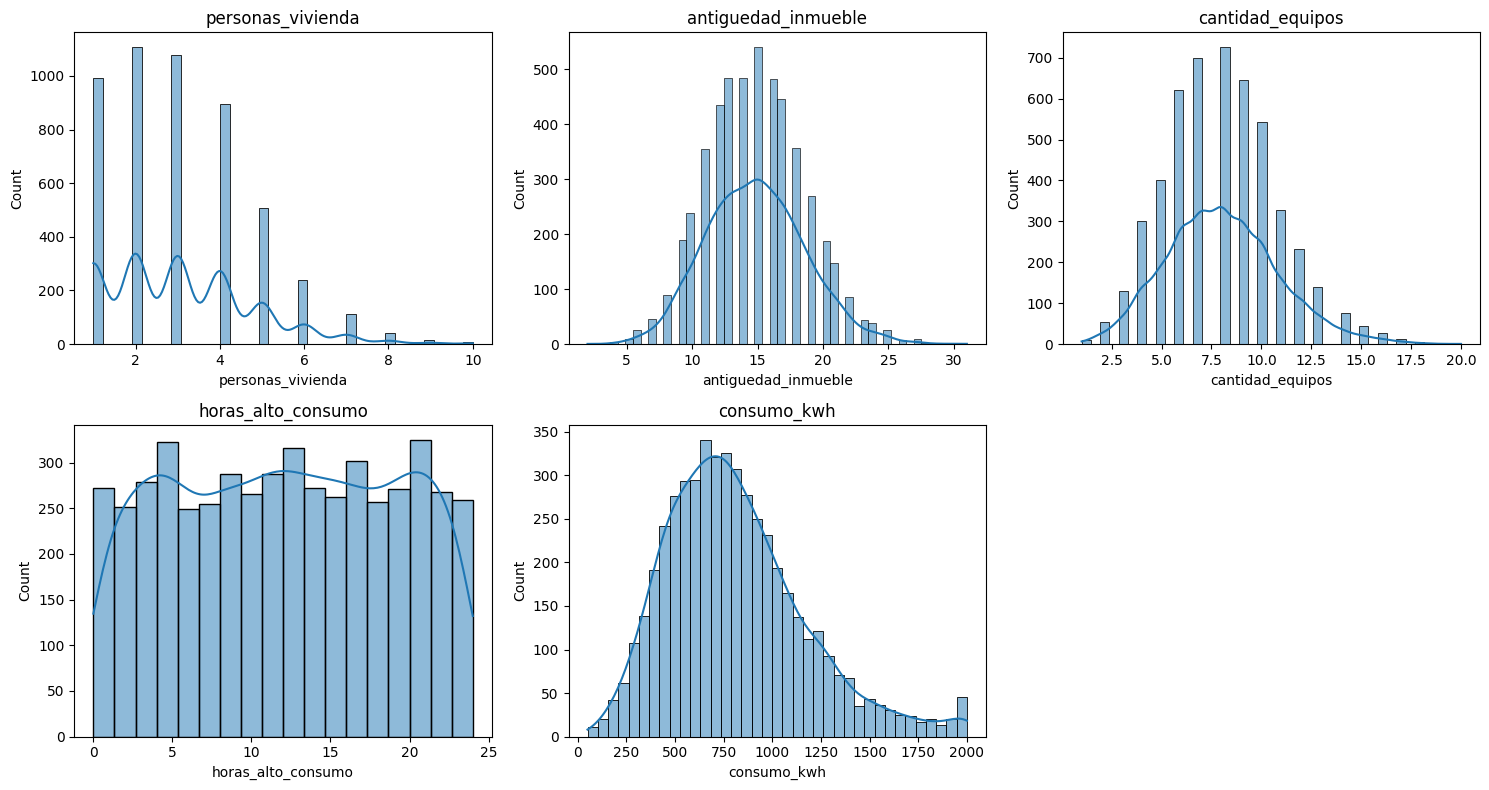

In [23]:
# Variables númericas continuas
variables_numericas = ["personas_vivienda", "antiguedad_inmueble", "cantidad_equipos", "horas_alto_consumo", "consumo_kwh"]

# Crear subgráficas
fig, axes = plt.subplots(
    nrows=(len(variables_numericas) + 2) // 3,
    ncols=3,
    figsize=(15, 4 * ((len(variables_numericas) + 2) // 3))
)
axes = axes.flatten()

# Graficar histogramas
for ax, column in zip(axes, variables_numericas):
    sns.histplot(
        data=df,
        x=column,
        kde=True,
        ax=ax
    )
    ax.set_title(column)

# Eliminar ejes sobrantes
for ax in axes[len(variables_numericas):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

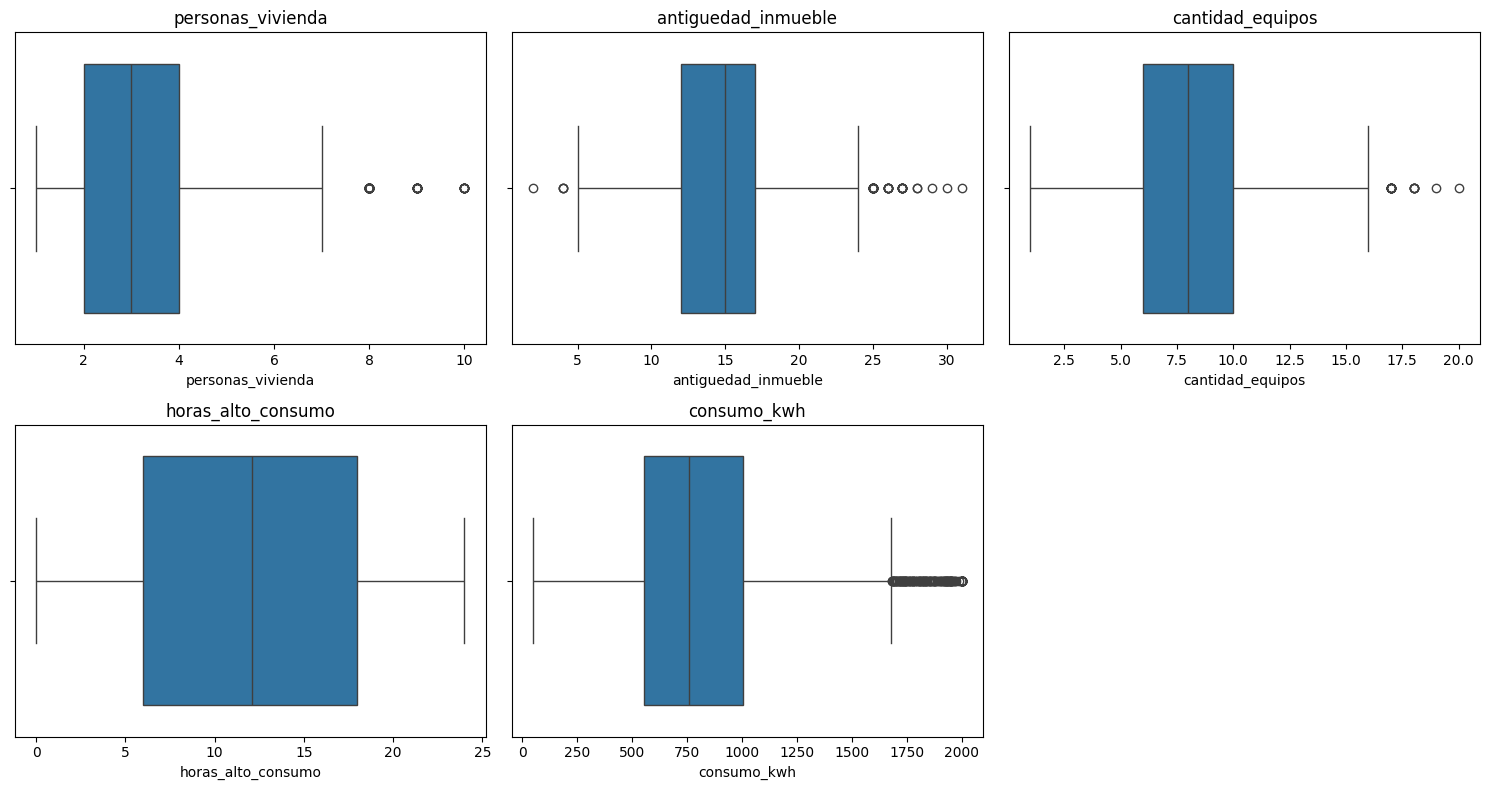

In [24]:
# Crear subgráficas
fig, axes = plt.subplots(
    nrows=(len(variables_numericas) + 2) // 3,
    ncols=3,
    figsize=(15, 4 * ((len(variables_numericas) + 2) // 3))
  )
axes = axes.flatten()

# Graficar histogramas
for ax, column in zip(axes, variables_numericas):
    sns.boxplot(x=df[column],ax=ax)
    ax.set_title(column)

# Eliminar ejes vacíos
for ax in axes[len(variables_numericas):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

### **Proporción de las variables binarias**

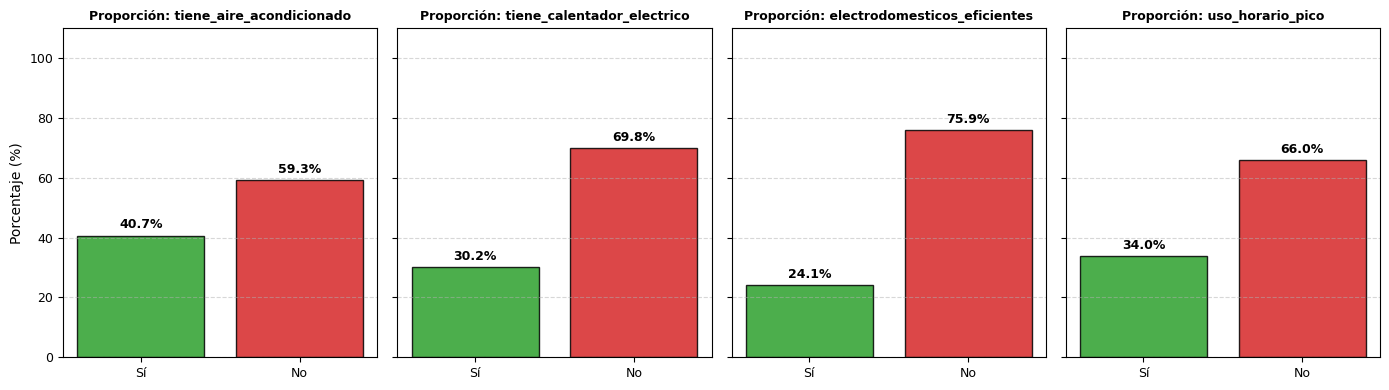

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

columnas_binarias = ['tiene_aire_acondicionado', 'tiene_calentador_electrico', 'electrodomesticos_eficientes', 'uso_horario_pico']

# 1. Crear la figura con una cuadrícula de 2x2
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)

for i, col in enumerate(columnas_binarias):
    ax = axes[i]

    # 2. Contar frecuencias de 0 y 1, asegurando que ambos existan (incluso si hay ceros)
    conteos = df[col].value_counts().reindex([1, 0], fill_value=0)

    # Calcular los porcentajes (proporciones)
    porcentajes = (conteos / conteos.sum()) * 100

    # 3. Dibujar las barras (1 -> 'Sí' en verde/azul, 0 -> 'No' en rojo/gris)
    colores = ['#2ca02c', '#d62728']  # Colores amigables para Sí y No
    barras = ax.bar(['Sí', 'No'], porcentajes, color=colores, alpha=0.85, edgecolor='black')

    # 4. Configurar títulos y etiquetas
    ax.set_title(f'Proporción: {col}', fontsize=9, fontweight='bold')

    ax.set_ylabel('Porcentaje (%)' if i == 0 else '')
    ax.set_ylim(0, 110)  # Dejar espacio arriba para las etiquetas de texto
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.tick_params(labelsize=9)

    # 5. Agregar el porcentaje en texto sobre cada barra
    for barra in barras:
        alto = barra.get_height()
        ax.annotate(f'{alto:.1f}%',
                    xy=(barra.get_x() + barra.get_width() / 2, alto),
                    xytext=(0, 3),  # Desplazamiento de 3 puntos hacia arriba
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# Ajustar los espacios entre subgráficos automáticamente
plt.tight_layout()
plt.show()

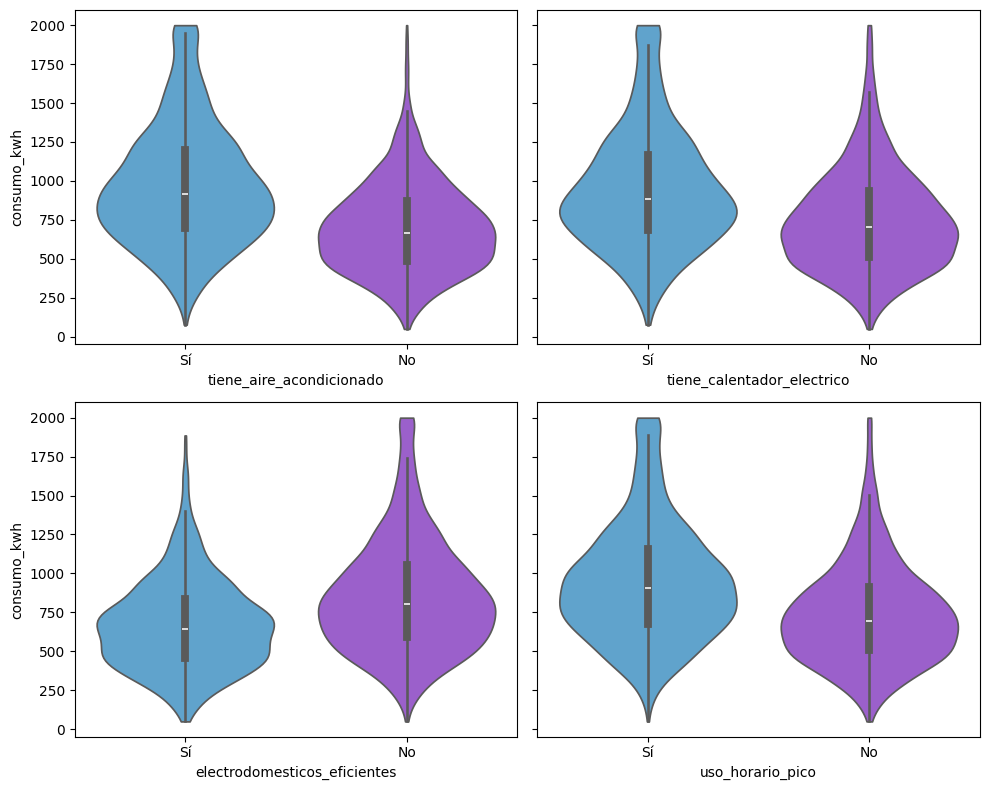

In [26]:
# Tus variables exactas
columnas_binarias = ['tiene_aire_acondicionado', 'tiene_calentador_electrico', 'electrodomesticos_eficientes', 'uso_horario_pico']

# 1. Crear una figura más compacta (reducida a 10x8)
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
axes = axes.flatten()

for i, col in enumerate(columnas_binarias):
    ax = axes[i]

    # 2. Copia temporal mapeando 1/0 a Sí/No
    df_temp = df[[col, 'consumo_kwh']].dropna()
    df_temp[col] = df_temp[col].map({1: 'Sí', 0: 'No'})

    # 3. Dibujar el Violinplot
    sns.violinplot(
        data=df_temp,
        x=col,
        y='consumo_kwh',
        hue=col,            # Solución al Warning: Asigna la variable x al parámetro hue
        legend=False,       # Oculta la leyenda repetitiva
        ax=ax,
        order=['Sí', 'No'],
        palette={'Sí': '#4ea8de', 'No': '#9d4edd'},
        inner='box',
        cut=0
    )

# Ajustar los espacios de manera compacta
plt.tight_layout()
plt.show()

**Interpretación:** Los principales vectores que elevan el consumo eléctrico en la muestra son el aire acondicionado y el calentador eléctrico, incrementando el consumo típico residencial en más de 200 kWh. Por el contrario, la incorporación de electrodomésticos eficientes demuestra un impacto real y medible en la reducción del consumo general. Finalmente, la variable de horario pico no altera el volumen neto de kWh consumidos al mes

### **Relación entre el tipo_inmueble y el consumo_kwh promedio**

   ✅ Visualizaciones guardadas como 'analisis_consumo_kwh.png'


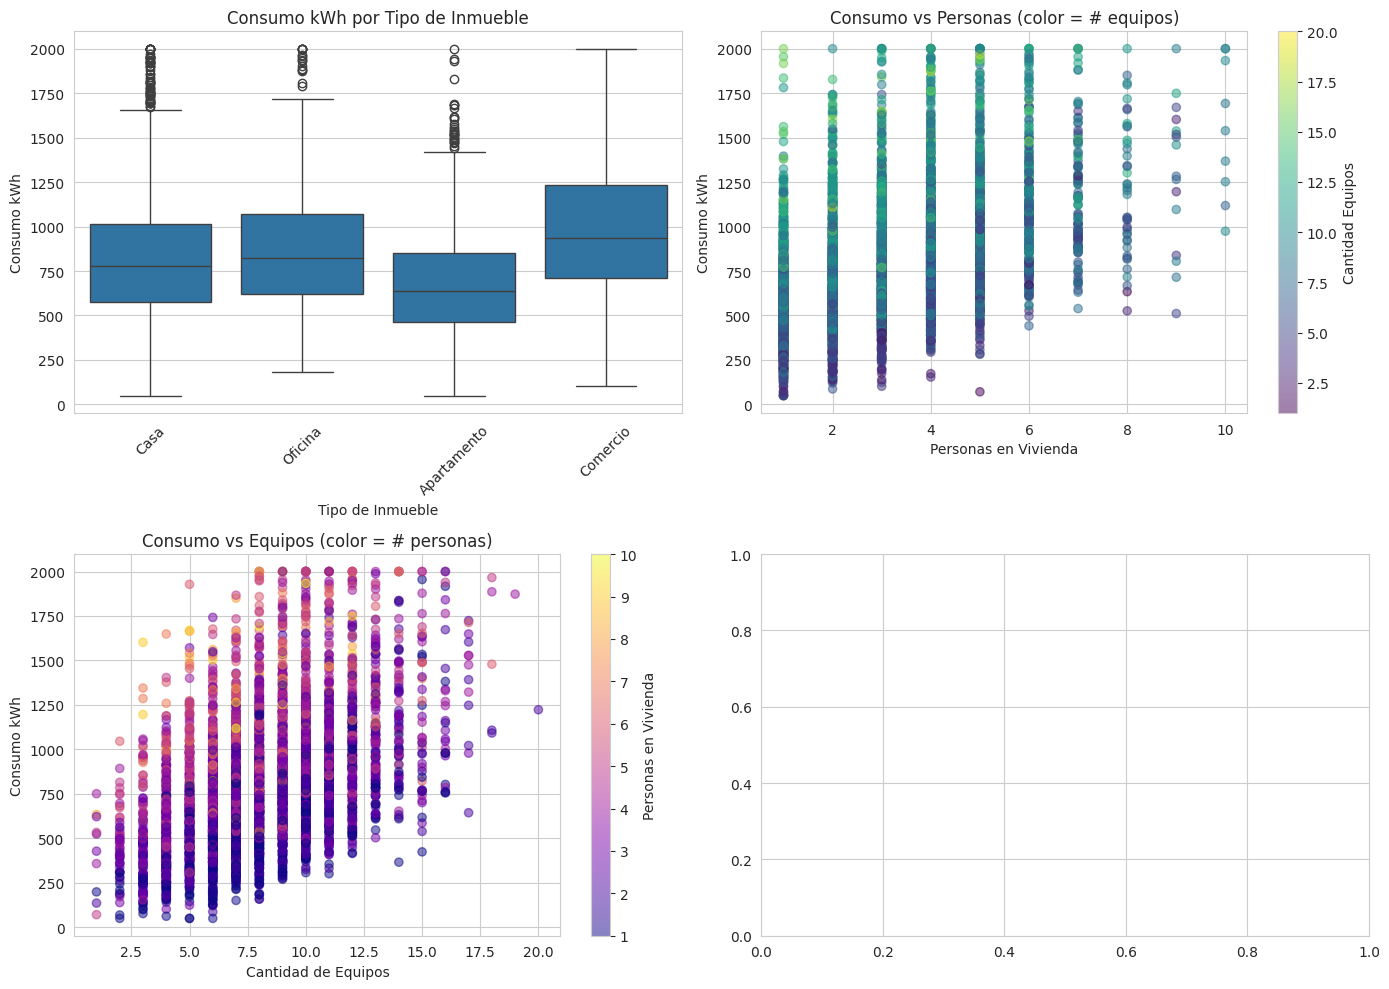

In [27]:
# Configurar estilo
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 5.1 Boxplot por tipo de inmueble
ax2 = axes[0, 0]
sns.boxplot(data=df, x='tipo_inmueble', y='consumo_kwh', ax=ax2)
ax2.set_title('Consumo kWh por Tipo de Inmueble', fontsize=12)
ax2.set_xlabel('Tipo de Inmueble')
ax2.set_ylabel('Consumo kWh')
ax2.tick_params(axis='x', rotation=45)

# 5.2 Scatter: Personas vs Consumo
ax3 = axes[0, 1]
scatter = ax3.scatter(df['personas_vivienda'], df['consumo_kwh'],
                     c=df['cantidad_equipos'], alpha=0.5, cmap='viridis')
ax3.set_title('Consumo vs Personas (color = # equipos)', fontsize=12)
ax3.set_xlabel('Personas en Vivienda')
ax3.set_ylabel('Consumo kWh')
plt.colorbar(scatter, ax=ax3, label='Cantidad Equipos')

# 5.3 Scatter: Equipos vs Consumo
ax4 = axes[1, 0]
scatter2 = ax4.scatter(df['cantidad_equipos'], df['consumo_kwh'],
                      c=df['personas_vivienda'], alpha=0.5, cmap='plasma')
ax4.set_title('Consumo vs Equipos (color = # personas)', fontsize=12)
ax4.set_xlabel('Cantidad de Equipos')
ax4.set_ylabel('Consumo kWh')
plt.colorbar(scatter2, ax=ax4, label='Personas en Vivienda')


plt.tight_layout()
plt.savefig('analisis_consumo_kwh.png', dpi=300, bbox_inches='tight')
print("   ✅ Visualizaciones guardadas como 'analisis_consumo_kwh.png'")
plt.show()

### **Analisis de correlaciones**


Análisis de correlaciones...
   ✅ Matriz de correlación guardada como 'matriz_correlacion.png'


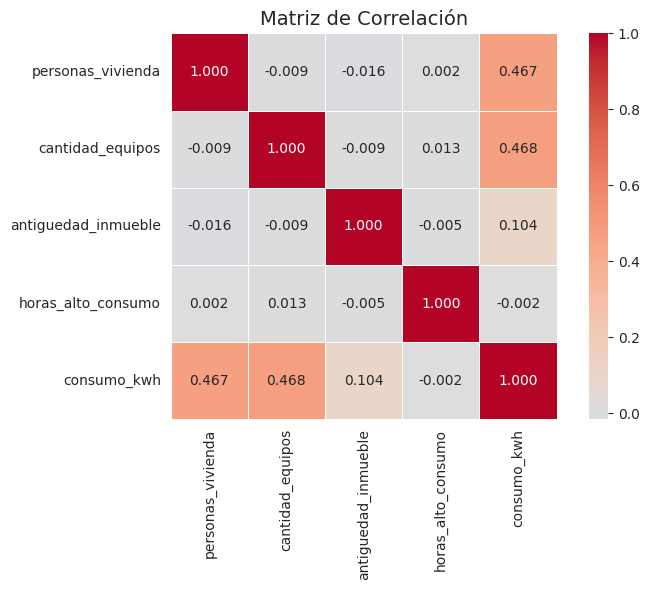

In [28]:
print("\nAnálisis de correlaciones...")

# Seleccionar variables numéricas para correlación
variables_corr = ['personas_vivienda', 'cantidad_equipos', 'antiguedad_inmueble',
                  'horas_alto_consumo', 'consumo_kwh']

correlation_matrix = df[variables_corr].corr()

# Gráfico de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, fmt='.3f')
plt.title('Matriz de Correlación', fontsize=14)
plt.tight_layout()
plt.savefig('matriz_correlacion.png', dpi=300, bbox_inches='tight')
print("   ✅ Matriz de correlación guardada como 'matriz_correlacion.png'")

## **4. Preprocesamiento Avanzado para Machine Learning**

## Consideraciones:
* ### Debe ser igual para todos los modelos: features, target, split train/val/test, tratamiento de nulos, codificación de categóricas (One-Hot Encoding para tipo_inmueble)
* ### El escalado no debe ser idéntico para todos los modelos, porque algunos modelos lo necesitan y otros no.
* ### Fuga de información (data leakage): categoria_eficiencia es una función determinista de consumo_kwh y personas_vivienda y su feature derivado. Esto inflará artificialmente las métricas (accuracy ~0.99) y no generalizará a datos reales  **[Se modifico la regla de clasificación para que ya no sea tan determinista]**

## Criterios para elegir los features para entrenamiento:
* ### No disponible en producción → excluir.
* ### Redundante → excluir (no aporta, y puede confundir la interpretabilidad).
* ### Produce leakage (función determinista del target o de variables que lo definen)→ excluir.

In [29]:
columnas_features = ['tipo_inmueble', 'personas_vivienda', 'antiguedad_inmueble', 'cantidad_equipos', 'tiene_aire_acondicionado',
       'tiene_calentador_electrico', 'electrodomesticos_eficientes', 'uso_horario_pico', 'horas_alto_consumo', 'consumo_kwh']
columna_target = 'categoria_eficiencia'

### **4.1 División del Dataset (Train / Test Split)**
Separación del dataset en conjunto de entrenamiento ($80\%$) y prueba ($20\%$) manteniendo estratificación respecto a la variable objetivo (categoria).  

In [30]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

RANDOM_STATE = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.2

X = df[columnas_features]
y = df[columna_target]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

val_size_ajustado = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_size_ajustado, stratify=y_temp, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Distribución train:\n{y_train.value_counts(normalize=True)}")

Train: (3000, 10), Val: (1000, 10), Test: (1000, 10)
Distribución train:
categoria_eficiencia
Eficiente      0.339667
Ineficiente    0.331667
Moderado       0.328667
Name: proportion, dtype: float64


### **4.1 Preprocesador: Codificacion de Variables Categóricas y numéricas**
Aplicación de One-Hot Encoding para la variable tipo_inmueble ("Casa", "Apartamento", "Comercio", etc.).  
Aplicación de StandardScaler si es necesario

In [31]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

COLUMNAS_CATEGORICAS = ['tipo_inmueble']
COLUMNAS_NUMERICAS = [c for c in columnas_features if c not in COLUMNAS_CATEGORICAS]

def crear_preprocesador(escalar=False):
    """Crea ColumnTransformer con One-Hot y (opcionalmente) StandardScaler."""
    num_transformer = StandardScaler() if escalar else 'passthrough'
    return ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), COLUMNAS_CATEGORICAS),
            ('num', num_transformer, COLUMNAS_NUMERICAS),
        ],
        remainder='drop'
    )

## **5. Modelado de Machine Learning (Supervisado)**

## **`5.1. Crear pipeline`**

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

def crear_pipelines():
    prep_sin = crear_preprocesador(escalar=False)
    prep_con = crear_preprocesador(escalar=True)

    return {
        # === Sin escalado ===
        'DecisionTree': Pipeline([
            ('prep', prep_sin),
            ('clf', DecisionTreeClassifier(
                max_depth=10, min_samples_leaf=5, class_weight='balanced',
                random_state=RANDOM_STATE
            ))
        ]),
        'RandomForest': Pipeline([
            ('prep', prep_sin),
            ('clf', RandomForestClassifier(
                n_estimators=200, max_depth=15, min_samples_leaf=5,
                class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
            ))
        ]),
        'GradientBoosting': Pipeline([
            ('prep', prep_sin),
            ('clf', GradientBoostingClassifier(
                n_estimators=200, learning_rate=0.1, max_depth=3,
                min_samples_split=10, min_samples_leaf=5, subsample=0.8,
                random_state=RANDOM_STATE
            ))
        ]),
        'XGBoost': Pipeline([
            ('prep', prep_sin),
            ('clf', XGBClassifier(
                n_estimators=200, learning_rate=0.1, max_depth=6,
                subsample=0.8, colsample_bytree=0.8,
                reg_alpha=0.1, reg_lambda=1.0,
                random_state=42, eval_metric='mlogloss', n_jobs=-1
            ))
        ]),
        # === Con escalado ===
        'LogisticRegression': Pipeline([
            ('prep', prep_con),
            ('clf', LogisticRegression(
                C=0.1,
                max_iter=1000, class_weight='balanced',
                random_state=RANDOM_STATE, n_jobs=-1
            ))
        ]),
        'SVM': Pipeline([
            ('prep', prep_con),
            ('clf', SVC(
                kernel='rbf', C=1.0, gamma='scale',
                probability=True, class_weight='balanced',
                random_state=RANDOM_STATE
            ))
        ]),
    }


### **5.2. Agregar LabelEncoder para el XGBoost**

In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)
print(f"\nClases codificadas: {dict(zip(le.classes_, le.transform(le.classes_)))}")


Clases codificadas: {'Eficiente': np.int64(0), 'Ineficiente': np.int64(1), 'Moderado': np.int64(2)}


### **5.3. Entrenamiento y evaluación de métricas**

In [34]:
import time
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import matthews_corrcoef

def evaluar(nombre, pipeline, X_train, y_train, X_val, y_val, X_test, y_test,
            le=None, y_train_enc=None, y_val_enc=None, y_test_enc=None):
    """Entrena y evalúa. Maneja XGBoost con target codificado."""

    start = time.time()
    if nombre == 'XGBoost':
        pipeline.fit(X_train, y_train_enc)
        y_val_pred_enc = pipeline.predict(X_val)
        y_test_pred_enc = pipeline.predict(X_test)
        y_val_pred = le.inverse_transform(y_val_pred_enc)
        y_test_pred = le.inverse_transform(y_test_pred_enc)
    else:
        pipeline.fit(X_train, y_train)
        y_val_pred = pipeline.predict(X_val)
        y_test_pred = pipeline.predict(X_test)
    tiempo = time.time() - start

    metricas = {'tiempo_entrenamiento': tiempo}
    for split, y_true, y_pred in [('val', y_val, y_val_pred), ('test', y_test, y_test_pred)]:
        metricas[f'{split}_accuracy'] = accuracy_score(y_true, y_pred)
        metricas[f'{split}_f1_macro'] = f1_score(y_true, y_pred, average='macro')
        metricas[f'{split}_f1_weighted'] = f1_score(y_true, y_pred, average='weighted')
        metricas[f'{split}_balanced_acc'] = balanced_accuracy_score(y_true, y_pred)
        metricas[f'{split}_mcc'] = matthews_corrcoef(y_true, y_pred)

    return metricas, y_test_pred

| Métrica | Qué evalúa | Cómo aporta a elegir al ganador |
| --- | --- | --- |
| **Accuracy** | Proporción de predicciones correctas sobre el total. | Métrica global simple. Con clases balanceadas es informativa, pero no distingue errores por clase. |
| **F1-macro** | Media armónica de precision y recall, promediada sin ponderar por clase. | Criterio principal. Trata las 3 clases con igual peso. Robusta a desbalances residuales. Es la métrica más exigente en multiclase. |
| **F1-weighted** | F1 promediado ponderando por el soporte de cada clase. | Útil si las clases mayoritarias importan más. Con clases balanceadas converge con F1-macro. |
| **Balanced Accuracy** | Media de los recalls por clase. | Alternativa a accuracy cuando hay desbalance. Con clases balanceadas, similar a accuracy. |
| **MCC (Matthews Correlation Coefficient)** | Correlación entre predicción y realidad. Va de -1 a +1. | Criterio de desempate. Robusto a desbalance y a tamaños de clase. Un MCC alto indica buen rendimiento global. |

In [35]:
pipelines = crear_pipelines()
resultados = {}
predicciones_test = {}

print("ENTRENAMIENTO Y EVALUACIÓN")
print("="*60)

for nombre, pipeline in pipelines.items():
    print(f"\n=== {nombre} ===")
    metricas, y_test_pred = evaluar(
        nombre, pipeline, X_train, y_train, X_val, y_val, X_test, y_test,
        le=le, y_train_enc=y_train_enc, y_val_enc=y_val_enc, y_test_enc=y_test_enc
    )
    resultados[nombre] = metricas
    predicciones_test[nombre] = y_test_pred
    for k, v in metricas.items():
        print(f"  {k}: {v:.4f}")

ENTRENAMIENTO Y EVALUACIÓN

=== DecisionTree ===
  tiempo_entrenamiento: 0.0523
  val_accuracy: 0.8870
  val_f1_macro: 0.8875
  val_f1_weighted: 0.8877
  val_balanced_acc: 0.8869
  val_mcc: 0.8309
  test_accuracy: 0.8990
  test_f1_macro: 0.8997
  test_f1_weighted: 0.9000
  test_balanced_acc: 0.8991
  test_mcc: 0.8496

=== RandomForest ===
  tiempo_entrenamiento: 1.0226
  val_accuracy: 0.9200
  val_f1_macro: 0.9206
  val_f1_weighted: 0.9208
  val_balanced_acc: 0.9201
  val_mcc: 0.8807
  test_accuracy: 0.9170
  test_f1_macro: 0.9179
  test_f1_weighted: 0.9182
  test_balanced_acc: 0.9171
  test_mcc: 0.8774

=== GradientBoosting ===
  tiempo_entrenamiento: 3.2098
  val_accuracy: 0.9390
  val_f1_macro: 0.9388
  val_f1_weighted: 0.9389
  val_balanced_acc: 0.9388
  val_mcc: 0.9085
  test_accuracy: 0.9470
  test_f1_macro: 0.9472
  test_f1_weighted: 0.9473
  test_balanced_acc: 0.9470
  test_mcc: 0.9208

=== XGBoost ===
  tiempo_entrenamiento: 0.6366
  val_accuracy: 0.9390
  val_f1_macro: 0.9389

### **Criterios para elegir al modelo ganador**
| Métrica | Qué evalúa | Cómo aporta a elegir al ganador |
| --- | --- | --- |
| **Precision (por clase)** | De los predichos como clase $k$, ¿cuántos son correctos? | Diagnóstico: si es baja, el modelo sobrepredice esa clase. |
| **Recall (por clase)** | De los reales de clase $k$, ¿cuántos detecto? | Diagnóstico: si es bajo, el modelo no detecta esa clase. |
| **Classification Report** | Vista completa por clase. | Diagnóstico cualitativo. Identifica clases problemáticas. |
| **Confusion Matrix** | Errores por par de clases. | Diagnóstico cualitativo. Identifica confusión entre clases específicas. |
| **Tiempo de entrenamiento** | Costo computacional del fit. | Criterio terciario. Si dos modelos empatan en F1-macro y MCC, elige el más rápido. |

In [36]:
# Selección del modelo ganador
df_resultados = pd.DataFrame(resultados).T
df_resultados = df_resultados.sort_values(
    ['val_f1_macro', 'val_mcc', 'tiempo_entrenamiento'],
    ascending=[False, False, True]
)

print("\n" + "="*60)
print("RANKING DE MODELOS")
print("="*60)
cols_mostrar = ['val_f1_macro', 'val_mcc', 'val_accuracy', 'test_f1_macro', 'test_mcc', 'tiempo_entrenamiento']
print(df_resultados[cols_mostrar].round(4))

modelo_ganador_nombre = df_resultados.index[0]
modelo_ganador = pipelines[modelo_ganador_nombre]

print(f"\n🏆 Modelo ganador: {modelo_ganador_nombre}")
print(f"   F1-macro val: {df_resultados.loc[modelo_ganador_nombre, 'val_f1_macro']:.4f}")
print(f"   F1-macro test: {df_resultados.loc[modelo_ganador_nombre, 'test_f1_macro']:.4f}")
print(f"   MCC val: {df_resultados.loc[modelo_ganador_nombre, 'val_mcc']:.4f}")

# Verificar overfitting
gap = abs(df_resultados.loc[modelo_ganador_nombre, 'val_f1_macro'] -
          df_resultados.loc[modelo_ganador_nombre, 'test_f1_macro'])
print(f"   Gap val-test: {gap:.4f} {'✅ OK' if gap < 0.05 else '⚠️ Posible overfitting'}")

# Reporte detallado
y_test_pred_ganador = predicciones_test[modelo_ganador_nombre]
print("\nClassification Report (test):")
print(classification_report(y_test, y_test_pred_ganador))
print("\nConfusion Matrix (test):")
print(confusion_matrix(y_test, y_test_pred_ganador, labels=sorted(y.unique())))


RANKING DE MODELOS
                    val_f1_macro  val_mcc  val_accuracy  test_f1_macro  \
SVM                       0.9599   0.9400         0.960         0.9502   
LogisticRegression        0.9401   0.9105         0.940         0.9463   
XGBoost                   0.9389   0.9085         0.939         0.9491   
GradientBoosting          0.9388   0.9085         0.939         0.9472   
RandomForest              0.9206   0.8807         0.920         0.9179   
DecisionTree              0.8875   0.8309         0.887         0.8997   

                    test_mcc  tiempo_entrenamiento  
SVM                   0.9255                0.9993  
LogisticRegression    0.9199                1.9602  
XGBoost               0.9237                0.6366  
GradientBoosting      0.9208                3.2098  
RandomForest          0.8774                1.0226  
DecisionTree          0.8496                0.0523  

🏆 Modelo ganador: SVM
   F1-macro val: 0.9599
   F1-macro test: 0.9502
   MCC val: 0.9400

### **5.2 Optimización de Hiperparámetros**
Ajuste fino de parámetros (n_estimators, max_depth, min_samples_split) mediante GridSearchCV o RandomizedSearchCV para evitar el sobreajuste (overfitting)

**Resultado**
> Se evaluó la pertinencia de optimizar hiperparámetros del modelo ganador. Dado que las métricas obtenidas para el modelo SVM tienen altas probabilidades hacer optmización arriesgaría a caer en overfitting.


## **6. Análisis de errores e interpretabilidad**

### **6.1 Importancia de Características por Permutación**
Toma tu conjunto de prueba, mide el rendimiento actual (ej. tu F1-macro de 0.95), y luego mezcla al azar los valores de una sola columna (destruyendo su relación con el target). Si el F1-macro se desploma catastróficamente, significa que esa variable es vital para el modelo. Si apenas cambia, la variable aporta poco.

In [37]:
from sklearn.inspection import permutation_importance

# Calcular la importancia por permutación en el conjunto de test
resultado_perm = permutation_importance(
    modelo_ganador, X_test, y_test,
    scoring='f1_macro', n_repeats=10,
    random_state=42, n_jobs=-1
)

# Mostrar los resultados ordenados
for i in resultado_perm.importances_mean.argsort()[::-1]:
    print(f"{columnas_features[i]}: "
          f"{resultado_perm.importances_mean[i]:.4f} "
          f"(+/- {resultado_perm.importances_std[i]:.4f})")

uso_horario_pico: 0.3444 (+/- 0.0205)
horas_alto_consumo: 0.2611 (+/- 0.0085)
electrodomesticos_eficientes: 0.2548 (+/- 0.0112)
antiguedad_inmueble: 0.0899 (+/- 0.0027)
cantidad_equipos: 0.0567 (+/- 0.0057)
consumo_kwh: 0.0549 (+/- 0.0073)
tipo_inmueble: 0.0108 (+/- 0.0036)
personas_vivienda: 0.0103 (+/- 0.0033)
tiene_aire_acondicionado: 0.0045 (+/- 0.0052)
tiene_calentador_electrico: 0.0001 (+/- 0.0019)


### **6.2. Identificación de errores**

In [39]:
# Identificar los hogares mal clasificados
y_pred = modelo_ganador.predict(X_test)
errores = X_test[y_pred != y_test].copy()
errores['real'] = y_test[y_pred != y_test]
errores['predicho'] = y_pred[y_pred != y_test]

# --- Matriz de Confusión de Errores ---
# Crea una matriz donde las filas son el valor real y las columnas el predicho
matriz_errores = pd.crosstab(errores['real'], errores['predicho'])
print("--- MATRIZ DE ERRORES (Real vs Predicho) ---")
print(matriz_errores)

--- MATRIZ DE ERRORES (Real vs Predicho) ---
predicho     Eficiente  Ineficiente  Moderado
real                                         
Ineficiente          0            0        17
Moderado             5            9         0
Eficiente            0            0        19


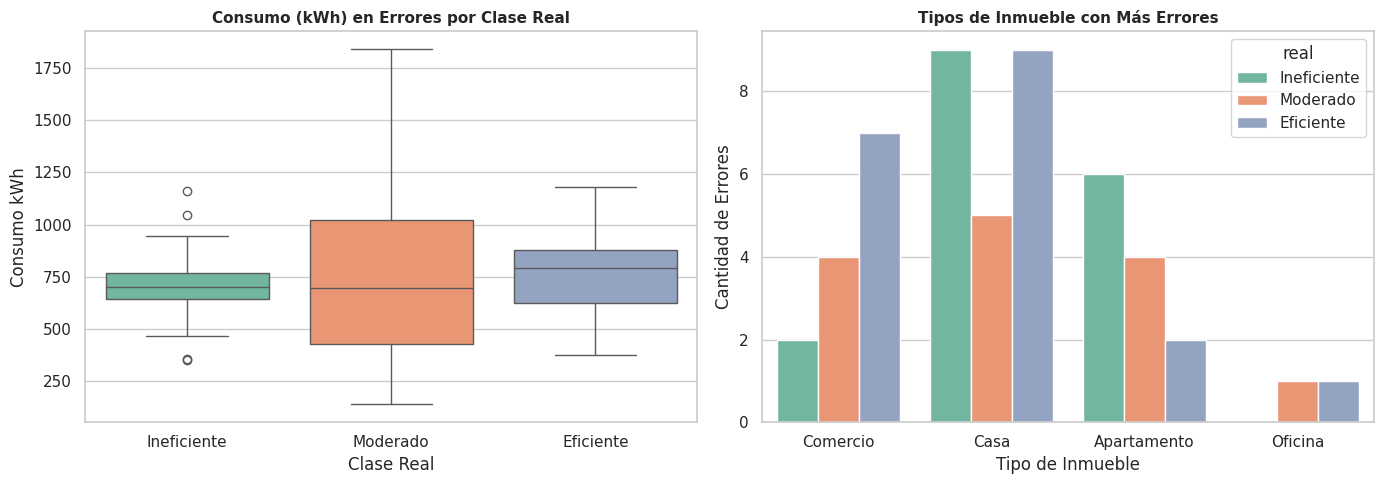

In [40]:
# Configurar estilo visual
sns.set_theme(style="whitegrid")

# --- Gráfico: Patrones en las Variables Clave de los Errores ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución del consumo en kWh para los errores según la clase real
sns.boxplot(data=errores, x='real', y='consumo_kwh', hue='real', ax=axes[0], palette='Set2', legend=False)
axes[0].set_title('Consumo (kWh) en Errores por Clase Real', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Clase Real')
axes[0].set_ylabel('Consumo kWh')

# Distribución del tipo de inmueble donde ocurren los errores
sns.countplot(data=errores, x='tipo_inmueble', hue='real', ax=axes[1], palette='Set2')
axes[1].set_title('Tipos de Inmueble con Más Errores', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Tipo de Inmueble')
axes[1].set_ylabel('Cantidad de Errores')

plt.tight_layout()
plt.show()

### **6.3. Curva ROC y AUC multiclase**

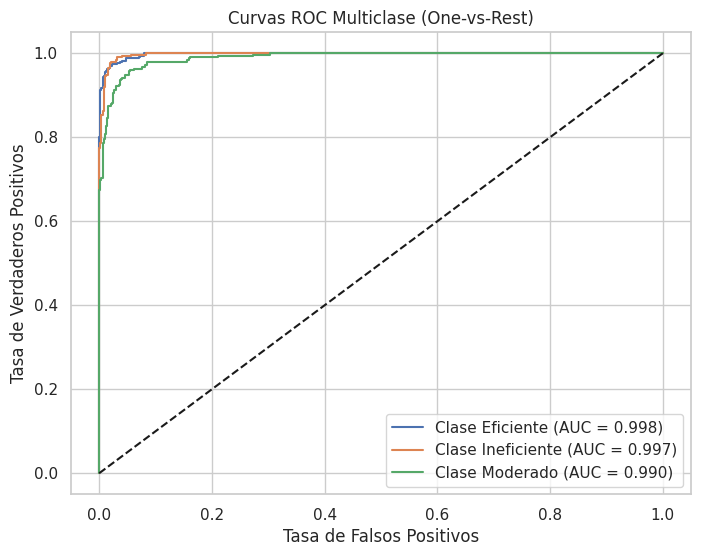

In [43]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Binarizar las etiquetas para multiclase
y_test_bin = label_binarize(y_test, classes=modelo_ganador.classes_)
y_proba = modelo_ganador.predict_proba(X_test)

plt.figure(figsize=(8, 6))
for i, clase in enumerate(modelo_ganador.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Clase {clase} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC Multiclase (One-vs-Rest)')
plt.legend(loc='lower right')
plt.show()

### **6.4. Robustez del modelo**

Añadir ruido sintético (perturbaciones aleatorias basadas en la desviación estándar de cada columna) simula exactamente esas pequeñas imperfecciones del entorno. Si un modelo es frágil, ante la mínima alteración en los datos de entrada, sus predicciones cambiarán drásticamente y su rendimiento se vendrá abajo. Si es robusto, mantendrá un buen desempeño a pesar de las alteraciones.

In [46]:
for ruido in [0.01, 0.05, 0.1]:
    X_test_ruidoso = X_test.copy()
    for col in COLUMNAS_NUMERICAS:
        X_test_ruidoso[col] += np.random.normal(0, ruido * X_test[col].std(), len(X_test))
    y_pred_ruidoso = modelo_ganador.predict(X_test_ruidoso)
    f1 = f1_score(y_test, y_pred_ruidoso, average='macro')
    print(f"Ruido {ruido}: F1-macro = {f1:.4f}")

Ruido 0.01: F1-macro = 0.9482
Ruido 0.05: F1-macro = 0.9462
Ruido 0.1: F1-macro = 0.9412


## **7. Serialización e Integración Cloud (OCI)**

In [47]:
import joblib
import json
import hashlib
from datetime import datetime
from pathlib import Path

# 1. Configuración
VERSION = '1.0.0'
MODELOS_DIR = Path('/content/modelos')
MODELOS_DIR.mkdir(exist_ok=True, parents=True)

modelo_path = MODELOS_DIR / f'modelo_energia_v{VERSION}.pkl'
metadata_path = MODELOS_DIR / f'modelo_energia_v{VERSION}_metadata.json'

# 2. Guardar el pipeline ganador
joblib.dump(modelo_ganador, modelo_path)
print(f"✅ Modelo guardado en: {modelo_path}")

# 3. Calcular hash (integridad)
with open(modelo_path, 'rb') as f:
    modelo_bytes = f.read()
modelo_hash = hashlib.sha256(modelo_bytes).hexdigest()
print(f"🔐 SHA256: {modelo_hash}")

# 4. Metadata del modelo
metadata = {
    'version': VERSION,
    'fecha_entrenamiento': datetime.now().isoformat(),
    'modelo_nombre': modelo_ganador_nombre,
    'tipo_modelo': type(modelo_ganador.named_steps['clf']).__name__,
    'features': columnas_features,
    'columnas_categoricas': COLUMNAS_CATEGORICAS,
    'columnas_numericas': COLUMNAS_NUMERICAS,
    'target': columna_target,
    'clases': list(modelo_ganador.classes_),
    'metricas': resultados[modelo_ganador_nombre],
    'dataset_size': len(df),
    'train_size': len(X_train),
    'val_size': len(X_val),
    'test_size': len(X_test),
    'random_state': RANDOM_STATE,
    'hash_modelo': modelo_hash,
    'usa_escalado': modelo_ganador_nombre in ['LogisticRegression', 'SVM'],
}

with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"✅ Metadata guardada en: {metadata_path}")

# 5. Listar archivos generados
print("\n📁 Archivos en /content/modelos/:")
for f in MODELOS_DIR.iterdir():
    size_kb = f.stat().st_size / 1024
    print(f"   {f.name} ({size_kb:.1f} KB)")

✅ Modelo guardado en: /content/modelos/modelo_energia_v1.0.0.pkl
🔐 SHA256: a87c088a27b321022cf9ffa737452598608b384f9b6845005d797cf80d161a00
✅ Metadata guardada en: /content/modelos/modelo_energia_v1.0.0_metadata.json

📁 Archivos en /content/modelos/:
   modelo_energia_v1.0.0_metadata.json (1.5 KB)
   modelo_energia_v1.0.0.pkl (129.1 KB)


### **8 Simulación de Entrada y Salida (Endpoint Simulation)**

- Construcción de la función analizar_consumo(payload) para emular el comportamiento del endpoint REST POST /analise-energetica.  
- Prueba integral utilizando el JSON de ejemplo provisto por el requerimiento:  
  - Input Test: {"consumo_kwh": 420, "uso_horario_pico": true, "cantidad_equipos": 10, "tipo_inmueble": "Casa", "horas_alto_consumo": 8}.  
  - Output Esperado: Estructura JSON con categoria, probabilidad, costo_estimado_mensual y recomendaciones

In [48]:
import joblib
import pickle

# 1. Cargar modelo (incluye el preprocesamiento)
modelo_cargado = joblib.load("/content/modelos/modelo_energia_v1.0.0.pkl")
print(f"✅ Modelo cargado: {type(modelo_cargado).__name__}")
print(f"   Clases: {modelo_cargado.classes_}")

✅ Modelo cargado: Pipeline
   Clases: ['Eficiente' 'Ineficiente' 'Moderado']


In [69]:
casos = [
    {
        'tipo_inmueble': 'Apartamento',
        'personas_vivienda': 2,
        'antiguedad_inmueble': 5,
        'cantidad_equipos': 6,
        'tiene_aire_acondicionado': 0,
        'tiene_calentador_electrico': 0,
        'electrodomesticos_eficientes': 1,
        'uso_horario_pico': 0,
        'horas_alto_consumo': 4.0,
        'consumo_kwh': 120.0,
    },
    {
        'tipo_inmueble': 'Comercio',
        'personas_vivienda': 8,
        'antiguedad_inmueble': 30,
        'cantidad_equipos': 20,
        'tiene_aire_acondicionado': 1,
        'tiene_calentador_electrico': 1,
        'electrodomesticos_eficientes': 0,
        'uso_horario_pico': 1,
        'horas_alto_consumo': 14.0,
        'consumo_kwh': 1500.0,
    },
    {
        'tipo_inmueble': 'Oficina',
        'personas_vivienda': 3,
        'antiguedad_inmueble': 10,
        'cantidad_equipos': 12,
        'tiene_aire_acondicionado': 1,
        'tiene_calentador_electrico': 0,
        'electrodomesticos_eficientes': 1,
        'uso_horario_pico': 0,
        'horas_alto_consumo': 6.0,
        'consumo_kwh': 350.0,
    },
    {
        'tipo_inmueble': 'Casa',
        'personas_vivienda': 2,
        'antiguedad_inmueble': 4,
        'cantidad_equipos': 5,
        'tiene_aire_acondicionado': 0,
        'tiene_calentador_electrico': 0,
        'electrodomesticos_eficientes': 1,
        'uso_horario_pico': 0,
        'horas_alto_consumo': 3.0,
        'consumo_kwh': 140.0,
    },
    {
        'tipo_inmueble': 'Casa',
        'personas_vivienda': 3,
        'antiguedad_inmueble': 12,
        'cantidad_equipos': 10,
        'tiene_aire_acondicionado': 0,
        'tiene_calentador_electrico': 1,
        'electrodomesticos_eficientes': 0,
        'uso_horario_pico': 0,
        'horas_alto_consumo': 9.0,
        'consumo_kwh': 880.0,
    },
    {
        'tipo_inmueble': 'Casa',
        'personas_vivienda': 6,
        'antiguedad_inmueble': 25,
        'cantidad_equipos': 18,
        'tiene_aire_acondicionado': 1,
        'tiene_calentador_electrico': 1,
        'electrodomesticos_eficientes': 0,
        'uso_horario_pico': 1,
        'horas_alto_consumo': 12.0,
        'consumo_kwh': 1100.0,
    }
]

X = df[columnas_features]
y = df[columna_target]

In [70]:
print("PRUEBA CON MÚLTIPLES CASOS")
print("="*60)
for i, caso in enumerate(casos, 1):
    df_caso = pd.DataFrame([caso])[columnas_features]
    pred = modelo_cargado.predict(df_caso)[0]
    proba = modelo_cargado.predict_proba(df_caso)[0]
    proba_dict = {c: round(float(p), 3) for c, p in zip(modelo_cargado.classes_, proba)}
    print(f"\nCaso {i} ({caso['tipo_inmueble']}, {caso['consumo_kwh']} kWh):")
    print(f"   Predicción: {pred}")
    print(f"   Probabilidades: {proba_dict}")

PRUEBA CON MÚLTIPLES CASOS

Caso 1 (Apartamento, 120.0 kWh):
   Predicción: Eficiente
   Probabilidades: {'Eficiente': 1.0, 'Ineficiente': 0.0, 'Moderado': 0.0}

Caso 2 (Comercio, 1500.0 kWh):
   Predicción: Ineficiente
   Probabilidades: {'Eficiente': 0.246, 'Ineficiente': 0.683, 'Moderado': 0.071}

Caso 3 (Oficina, 350.0 kWh):
   Predicción: Eficiente
   Probabilidades: {'Eficiente': 1.0, 'Ineficiente': 0.0, 'Moderado': 0.0}

Caso 4 (Casa, 140.0 kWh):
   Predicción: Eficiente
   Probabilidades: {'Eficiente': 1.0, 'Ineficiente': 0.0, 'Moderado': 0.0}

Caso 5 (Casa, 880.0 kWh):
   Predicción: Moderado
   Probabilidades: {'Eficiente': 0.24, 'Ineficiente': 0.001, 'Moderado': 0.758}

Caso 6 (Casa, 1100.0 kWh):
   Predicción: Ineficiente
   Probabilidades: {'Eficiente': 0.018, 'Ineficiente': 0.936, 'Moderado': 0.046}
